# **10장. 합성곱 신경망 모델의 원리와 구조**

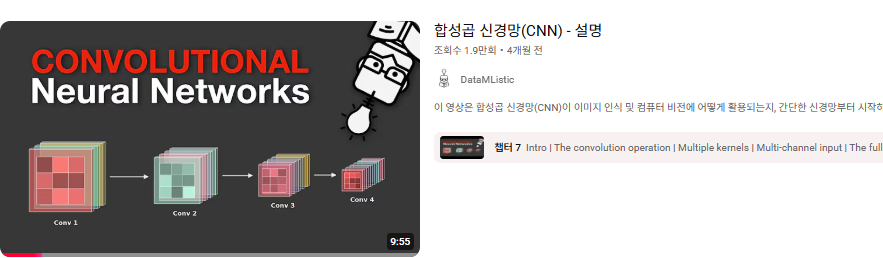

https://www.youtube.com/watch?v=YGILT182T6w&t=186s

이 동영상은 CNN의 특징과 구조를 잘 설명하고 있습니다.


---



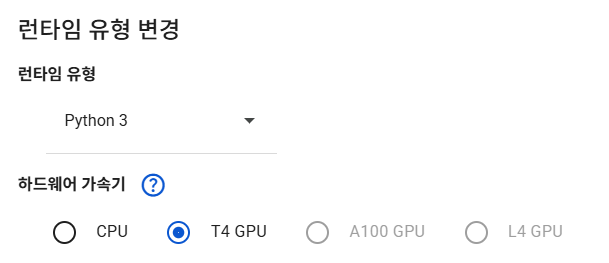

* CNN은 파라미터가 많아서 런타임 환경이 GPU로 설정되지 않으면 시간이 많이 걸릴수 있습니다.
* 런타임 유형을 GPU로 바꾸어 실행해봅시다.


In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
from tensorflow.keras.datasets import cifar10
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt; import random
import tensorflow as tf; from tensorflow import keras
import cv2
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalAveragePooling2D, Activation
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings; warnings.filterwarnings('ignore')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 59.5 MB/s eta 0:00:00


[실습 10-01]

In [ ]:
image = np.array(
    [[0, 1, 0, 1],
     [1, 2, 3, 4],
     [2, 3, 2, 0],
     [3, 4, 1, 2]])
print(f"이미지{image.shape}"); print(image); print()

filt=np.array(
    [[1, 0, -1],
     [1, 0, -1],
     [1, 0, -1]])
print(f"필터{filt.shape}"); print(filt); print()

def conv(input, filter):   # 합성곱 연산을 하는 사용자 정의 함수
  map=np.zeros(shape=(input.shape[0]-2, input.shape[1]-2)) # 특성맵 초기화
  for i in range(map.shape[0]):
    for j in range(map.shape[1]):
      patch=input[i:i+3, j:j+3]
      map[i, j] = np.sum(patch * filter)
  return map

f_map=conv(image, filt)
print(f"특성맵{f_map.shape}"); print(f_map)


이미지(4, 4)
[[0 1 0 1]
 [1 2 3 4]
 [2 3 2 0]
 [3 4 1 2]]

필터(3, 3)
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

특성맵(2, 2)
[[-2.  1.]
 [ 0.  3.]]


[실습 10-02]

패딩된 이미지(6, 6)
[[0 0 0 0 0 0]
 [0 0 1 0 1 0]
 [0 1 2 3 4 0]
 [0 2 3 2 0 0]
 [0 3 4 1 2 0]
 [0 0 0 0 0 0]]

특성맵(4, 4)
[[-3. -2. -2.  3.]
 [-6. -2.  1.  5.]
 [-9.  0.  3.  6.]
 [-7.  2.  5.  3.]]



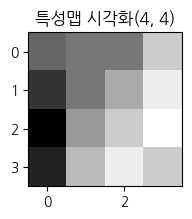

In [ ]:
pad_image=np.pad(image, pad_width=1, mode='constant') # 패딩

print(f"패딩된 이미지{pad_image.shape}"); print(pad_image); print()

f_map=conv(pad_image, filt)
print(f"특성맵{f_map.shape}"); print(f_map); print()

# 특성맵 시각화
plt.figure(figsize=(2, 2))
plt.imshow(f_map, cmap='gray')
plt.title(f"특성맵 시각화{f_map.shape}"); plt.show()

[실습 10-03]

맥스풀링된 특성 맵
[[-2.  5.]
 [ 2.  6.]]



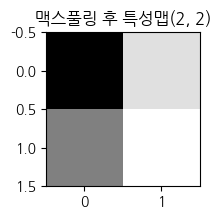

In [ ]:
# 맥스풀링 사용자 정의 함수
def max_pool(map, size):
  pool=np.zeros((map.shape[0] // size, f_map.shape[1] // size))
  for i in range(0, map.shape[0], size):
    for j in range(0, map.shape[1], size):
        # 특성맵의 2x2 영역에서 가장 큰 값만 추출
        frame = map[i:i+size, j:j+size]
        pool[i//size, j//size] = np.max(frame)
  return(pool)

pooled_map = max_pool(f_map, size=2)
print("맥스풀링된 특성 맵")
print(pooled_map); print()

# 풀링 결과 시각화
plt.figure(figsize=(2, 2))
plt.imshow(pooled_map, cmap='gray')
plt.title(f"맥스풀링 후 특성맵{pooled_map.shape}"); plt.show()

[실습 10-04]

수직선을 검출하는 필터
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]


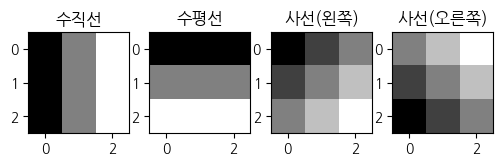

In [ ]:
# 일정한 패턴을 가진 필터 정의
filters = [
    np.array([[-1,  0,  1], [-1, 0, 1], [-1,  0,  1]]), # 0. 수직 엣지 검출
    np.array([[-1, -1, -1], [ 0, 0, 0], [ 1,  1,  1]]), # 1. 수평 엣지 검출
    np.array([[-2, -1,  0], [-1, 0, 1], [ 0,  1,  2]]), # 2. 사선 엣지 검출 (오른쪽 위 -> 왼쪽 아래)
    np.array([[ 0,  1,  2], [-1, 0, 1], [-2, -1,  0]])  # 3. 사선 엣지 검출 (왼쪽 위 -> 오른쪽 아래)
    ]

filter_names = ["수직선", "수평선", "사선(왼쪽)", "사선(오른쪽)"]
print(f"{filter_names[0]}을 검출하는 필터")
print(filters[0])

plt.figure(figsize=(6, 6))

for i in range(4):
  plt.subplot(1,4, i+1)
  plt.imshow(filters[i], cmap='gray')
  plt.title(f"{filter_names[i]}");

plt.show()

[실습 10-05]

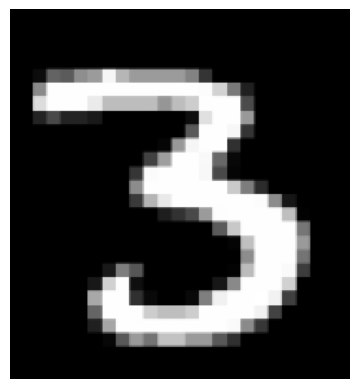

In [ ]:
# 샘플 이미지 로드
image = cv2.imread('mnist3.png', cv2.IMREAD_GRAYSCALE)  # 1채널로 변환
plt.imshow(image, cmap='gray')
plt.axis("off"); plt.show()

[실습 10-06]

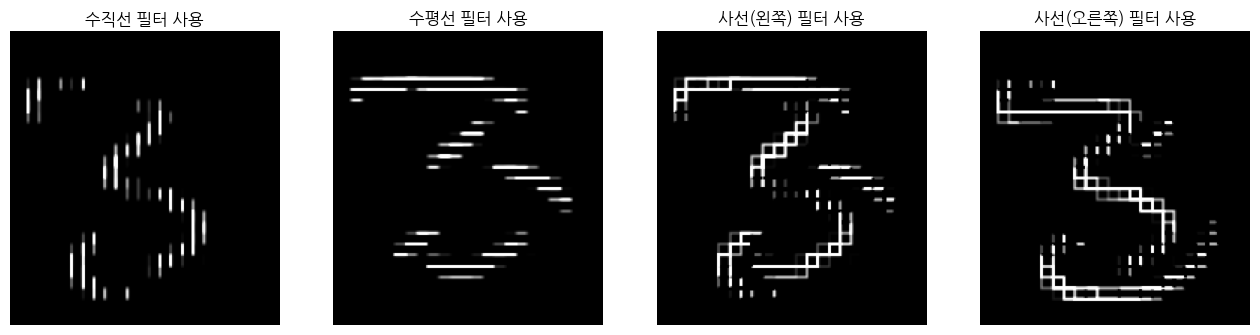

In [ ]:
plt.figure(figsize=(16, 12))
pad_image=np.pad(image, pad_width=1, mode='constant')

feature_maps = []

for i in range(len(filter_names)):
  plt.subplot(1,4, i+1)
  f_map=conv(pad_image, filters[i])
  f_map=np.clip(f_map, 0, 255)
  plt.imshow(f_map, cmap='gray'); plt.axis("off")
  plt.title(f"{filter_names[i]} 필터 사용")
  feature_maps.append(f_map)

[실습 10-07]

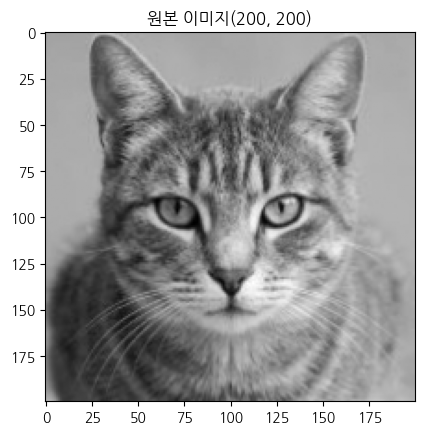

In [ ]:
image=cv2.imread('고양이.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')
plt.title(f"원본 이미지{image.shape}")
plt.show()

[실습 10-08]

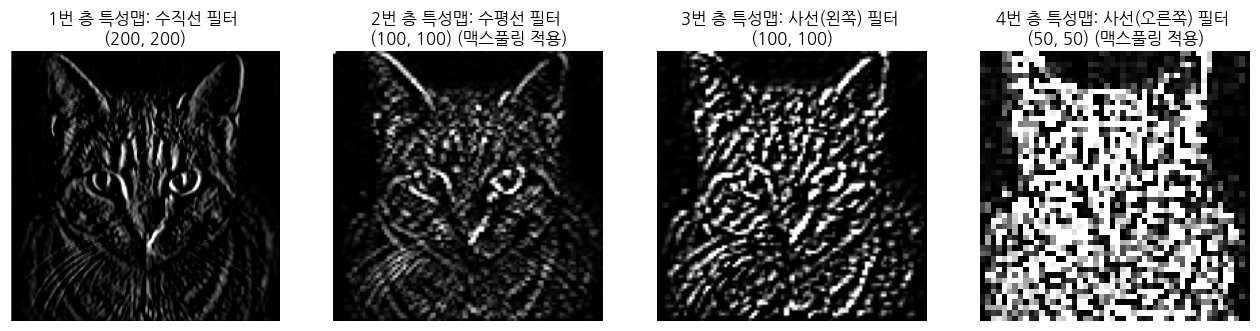

In [ ]:
# 4개 층을 연속 실행
num_layers=4
current_input = image.copy()

plt.figure(figsize=(16, 12))

for i in range(num_layers):
    filt = filters[i]
    pad_image = np.pad(current_input, 1, mode='constant') # 패딩
    f_map=conv(pad_image, filt)   # 특성 맵 계산
    f_map=np.clip(f_map, 0, 255)  # np.clip(f_map, 0, 255)은 특성맵의 값을 최소 0 최대 255로 제한

    if (i + 1) % 2 == 0:
        f_map = max_pool(f_map, size=2)
        pool_str = " (맥스풀링 적용)"
    else:
        pool_str = ""

    current_input = f_map

    plt.subplot(1, 4, i+1)
    plt.imshow(f_map, cmap='gray')
    plt.title(f"{i+1}번 층 특성맵: {filter_names[i]} 필터 \n{f_map.shape}{pool_str}"); plt.axis('off')

plt.show()